In [1]:
import pandas as pd
import numpy as np 
from pre_processing import xGPreprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier



In [2]:
df = pd.read_csv("../data/bronze/csv/statsbomb_shots_final.csv")

In [3]:

y = (df["shot_outcome"] == "Goal").astype(int)
# Importante tirar isso para evitar vazamento de dados
X = df.drop(columns=["shot_outcome"])

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [5]:
# 1. Definir quais colunas são texto
cat_features = ['play_pattern', 'shot_body_part', 'shot_technique', 'shot_type', 'foot_alignment']

# 2. Criar o Codificador
# Ele vai transformar as categorias em colunas 0/1
encoder = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
], remainder='passthrough') # 'passthrough' mantém as colunas numéricas (distância, x, y)

# 3. O Pipeline Unificado
final_pipeline = Pipeline([
    ('geometrias', xGPreprocessor()), # Seu arquivo pre_processing.py
    ('encoding', encoder),            # Transformação matemática
    ('classifier', CatBoostClassifier()) 
])

In [6]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'classifier__learning_rate': [0.03, 0.05, 0.1],
    'classifier__max_depth': [4, 6, 8],
    'classifier__n_estimators': [200, 500],
    'classifier__l2_leaf_reg': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=final_pipeline,
    param_distributions=param_grid,
    n_iter=15, # Ele vai testar apenas 15 combinações aleatórias
    cv=3,      # Reduzi para 3-fold para ir mais rápido
    scoring='neg_brier_score',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
0:	learn: 0.6601673	total: 68.4ms	remaining: 34.1s
0:	learn: 0.5899385	total: 68ms	remaining: 33.9s
0:	learn: 0.6032673	total: 68.5ms	remaining: 34.2s
0:	learn: 0.6023767	total: 68.3ms	remaining: 13.6s
0:	learn: 0.6646884	total: 68.2ms	remaining: 34s
0:	learn: 0.5899385	total: 68ms	remaining: 13.5s
0:	learn: 0.6023767	total: 68.6ms	remaining: 34.2s
0:	learn: 0.6643880	total: 68.8ms	remaining: 34.3s
1:	learn: 0.5243838	total: 69.5ms	remaining: 6.88s
1:	learn: 0.6351655	total: 69.5ms	remaining: 17.3s
1:	learn: 0.5190682	total: 69.3ms	remaining: 17.3s
1:	learn: 0.6324379	total: 69.7ms	remaining: 17.4s
2:	learn: 0.4677890	total: 70.2ms	remaining: 11.6s
2:	learn: 0.6083931	total: 70.6ms	remaining: 11.7s
1:	learn: 0.6348162	total: 71.1ms	remaining: 17.7s
2:	learn: 0.6106327	total: 70.8ms	remaining: 11.7s
2:	learn: 0.4687133	total: 70.8ms	remaining: 4.65s
1:	learn: 0.5243838	total: 71.3ms	remaining: 17.8s
1:	learn: 0.5190682	total: 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__l2_leaf_reg': [1, 3, ...], 'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [4, 6, ...], 'classifier__n_estimators': [200, 500]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_brier_score'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-v

In [7]:
random_search.predict_proba(X_test)

array([[0.96951476, 0.03048524],
       [0.85285255, 0.14714745],
       [0.64983614, 0.35016386],
       ...,
       [0.84427684, 0.15572316],
       [0.91392389, 0.08607611],
       [0.87255157, 0.12744843]], shape=(1982, 2))

In [8]:
# Pegamos a probabilidade da classe 1 (GOL)
probs_test = random_search.predict_proba(X_test)[:, 1]

# Criamos um DataFrame de análise
results_df = pd.DataFrame({
    'realidade': y_test.values,
    'xg_modelo': probs_test
})

# Mostrar os casos onde o modelo deu mais de 50% de chance de gol
print("Chutes com xG alto (> 0.5):")
display(results_df[results_df['xg_modelo'] > 0.5].head())

Chutes com xG alto (> 0.5):


,realidade,xg_modelo
72,0,0.693745
84,0,0.554202
97,0,0.677059
155,1,0.778799
156,1,0.743237


In [9]:
from sklearn.metrics import brier_score_loss, roc_auc_score

brier = brier_score_loss(y_test, probs_test)
auc = roc_auc_score(y_test, probs_test)

print(f"Brier Score no Teste: {brier:.4f}")
print(f"ROC AUC no Teste: {auc:.4f}")

Brier Score no Teste: 0.0748
ROC AUC no Teste: 0.7872


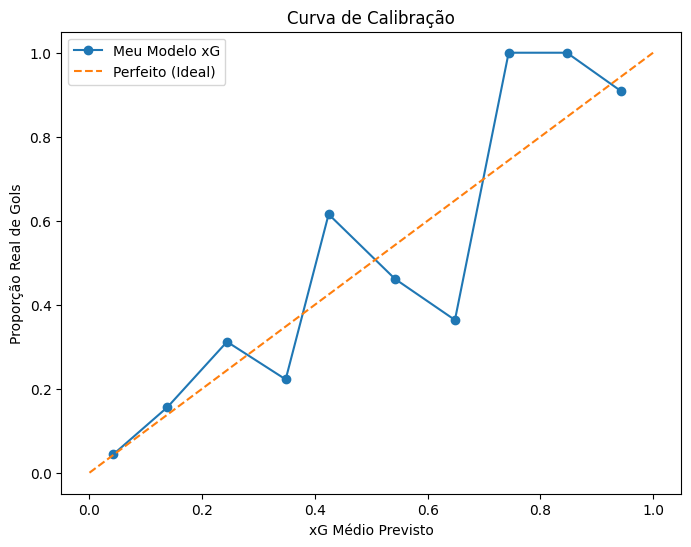

In [10]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, probs_test, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Meu Modelo xG')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfeito (Ideal)')
plt.xlabel('xG Médio Previsto')
plt.ylabel('Proporção Real de Gols')
plt.title('Curva de Calibração')
plt.legend()
plt.show()

In [11]:
import joblib
import os

# 1. Criar a pasta se não existir
os.makedirs('../models', exist_ok=True)

# 2. Salvar o melhor estimador encontrado pelo GridSearch
# O arquivo .pkl conterá: Geometria + Encoding + CatBoost Tunado
modelo_caminho = '../models/xg_pipeline_final.pkl'
joblib.dump(random_search.best_estimator_, modelo_caminho)


['../models/xg_pipeline_final.pkl']